# Compare all optimizers

Aggregate scoring metrics from [`scoring_one_optimizer.ipynb`](scoring_one_optimizer.ipynb) across every `(experiment, model, run, optimizer)` in [`scan_results()`](../app.py). Scoring logic lives in [`scoring_helpers.py`](scoring_helpers.py).

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import gzip
import pickle
import sys
from pathlib import Path
from typing import Any, cast

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from tqdm.auto import tqdm


def _find_project_root(start: Path | None = None) -> Path:
	p = (start or Path.cwd()).resolve()
	for cand in [p, *p.parents]:
		if (cand / "pyproject.toml").is_file():
			return cand
	return p


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
	sys.path.insert(0, str(PROJECT_ROOT))

from experiments.mnist import MNISTWrapper
from models import get_model

from visualize_webapp.app import (
	_NETWORK_SAMPLES_PER_DIGIT,
	_metrics,
	_nts,
	_opt_color,
	_sort_optimizer_ids,
	scan_results,
)
from visualize_webapp.notebook.scoring_helpers import (
	angle_score_function,
	filter_periods,
	find_impacted_periods,
	get_all_model_saliency_maps,
	get_all_points_of_max_acceleration,
	get_assignments,
	get_iteration,
	is_pretrain_shuffle_mislabel_experiment,
	get_neuron_saliency_maps_from_all,
	get_n_assigned_digits,
	get_period_angles,
	get_period_checkpoint_indices,
	compute_period_robustness_trajectory,
	get_period_scores_through_time,
	get_recovery_periods,
	init_cw_ssim_pyramid,
	length_score_function,
	n_active_decay,
	n_partial_decay,
	remove_inelligible_periods,
	index_grp,
)
from visualize_webapp.post_processing import _pp_dead, _pp_neuron_digit

SCORE_FACTORS = {
	"angle_score": 3.0,
	"length_score": 2.0,
	"n_partial_decay_score": 0.1,
	"n_active_decay_score": 0.1,
	"inverted_robustness_score": 3.0,
}
COMPUTATION_POINT = "max_activity"
EXPERT_MODEL_DIR = "local/save/expert_optimizer_pretrained/!OPT/"
STRICT = False
BTSP_START_STRATEGY = "acceleration"
USE_REAL_PROGRESSION = True
SAVE_DIR = "local/save/COMP/"


def _run_checkpoint_dir(save_dir: str, eid: str, oid: str) -> Path:
	import hashlib
	sha = hashlib.sha256(f"{eid}-{oid}".encode("utf-8")).hexdigest()[:7]
	return Path(save_dir) / sha


def _save_run_checkpoint(save_dir: str, eid: str, oid: str, out: dict[str, Any]) -> None:
	d = _run_checkpoint_dir(save_dir, eid, oid)
	d.mkdir(parents=True, exist_ok=True)
	pd.DataFrame([{"eid": eid, "oid": oid}]).to_csv(d / "key.csv", index=False)
	with gzip.open(d / "results.pkl.gz", "wb", compresslevel=9) as f:
		pickle.dump(out, f, protocol=pickle.HIGHEST_PROTOCOL)


def _load_run_checkpoint(save_dir: str, eid: str, oid: str) -> dict[str, Any] | None:
	d = _run_checkpoint_dir(save_dir, eid, oid)
	key_csv = d / "key.csv"
	res_gz = d / "results.pkl.gz"
	res_pkl = d / "results.pkl"
	if not key_csv.is_file() or (not res_gz.is_file() and not res_pkl.is_file()):
		return None
	key_df = pd.read_csv(key_csv)
	if len(key_df) != 1 or str(key_df["eid"].iloc[0]) != str(eid) or str(key_df["oid"].iloc[0]) != str(oid):
		return None
	if res_gz.is_file():
		with gzip.open(res_gz, "rb") as f:
			return pickle.load(f)
	with open(res_pkl, "rb") as f:
		return pickle.load(f)




In [3]:
PLOT_DIR = "local/save/plots/"
Path(PLOT_DIR).mkdir(parents=True, exist_ok=True)

In [4]:
class DummyExp(MNISTWrapper):
	def experiment_id(self):
		return ""

	def _build_trials(self, batch_size: int, seed: int, *, num_experiment_runs: int):
		return []


def _opt_display(oid: str) -> str:
	no_lr = oid.rsplit("_lr", 1)[0] if "_lr" in oid else oid
	return no_lr.replace("_"," ").capitalize()


def _empty_ssim_tt() -> pd.DataFrame:
	return pd.DataFrame(
		columns=index_grp + ["checkpoint_idx", "digit", "layer_name", "mean_of_mssim", "mssim_of_mean"]
	).set_index(index_grp + ["checkpoint_idx", "digit"])


def _empty_repr_tt() -> pd.DataFrame:
	return pd.DataFrame(
		columns=index_grp + ["checkpoint_idx", "representation_similarity_factor"]
	).set_index(index_grp + ["checkpoint_idx"])


def collect_score_run_data(
	eid: str,
	mid: str,
	oid: str,
	rid: str,
	prebuilt_pyramids: dict,
	project_root: Path | None = None,
	expert_saliency_by_oid: dict[str, dict] | None = None,
) -> dict[str, Any]:
	"""Heavy path: expert saliency, through-time SSIM/repr dfs, robustness df, prefix score tables.

	Does not compute ``mean_total_score`` or ``mssim_rows`` / ``period_robustness_rows`` lists
	(use ``score_from_collected_data``). Mutates ``prebuilt_pyramids`` and optionally
	``expert_saliency_by_oid``.
	"""
	root = project_root or PROJECT_ROOT
	is_shuffle_mislabel = is_pretrain_shuffle_mislabel_experiment(eid)
	peak_agg = "max" if is_shuffle_mislabel else "min"
	metrics = _metrics(eid, mid, oid, rid=rid, w_cache=False)
	df_nd = cast(pd.DataFrame, _pp_neuron_digit(eid, mid, oid, rid=rid, w_cache=False))
	if df_nd is None or df_nd.empty:
		return {"error": "empty neuron_digit", "eid": eid, "mid": mid, "oid": oid, "rid": rid}

	df_nd = df_nd.copy()
	df_nd["n_active"] = df_nd["status"].apply(
		lambda s: 0
		if s == "inactive"
		else (_NETWORK_SAMPLES_PER_DIGIT if s == "assigned" else int(s.split("_")[-1]))
	)
	df_nd["iteration"] = df_nd["checkpoint_idx"].map(lambda c: get_iteration(metrics, c))

	df_dead = cast(pd.DataFrame, _pp_dead(eid, mid, oid, rid=rid, w_cache=False))
	if df_dead is not None and not df_dead.empty:
		df_dead = df_dead.copy()
		df_dead["iteration"] = df_dead["checkpoint_idx"].map(lambda c: get_iteration(metrics, c))

	nts = _nts(eid, mid, oid, rid=rid, w_cache=False)

	n_assigned_digits = get_n_assigned_digits(df_nd)
	recovery_periods_any = get_recovery_periods(
		metrics, df_nd, n_assigned_digits, df_dead, mode="assigned_any"
	)
	recovery_periods_same = get_recovery_periods(
		metrics, df_nd, n_assigned_digits, df_dead, mode="assigned_same"
	)
	impacted = find_impacted_periods(recovery_periods_any, recovery_periods_same)
	n_any = len(recovery_periods_any)
	impacted_pct = float(len(impacted) / n_any) if n_any else 0.0

	recovery_periods = recovery_periods_same
	recovery_periods = remove_inelligible_periods(
		recovery_periods, require_until_trial_end=not is_shuffle_mislabel
	)
	if df_dead is not None and not df_dead.empty:
		recovery_periods = filter_periods(recovery_periods, df_dead, strict=STRICT)

	if recovery_periods.empty:
		return {
			"eid": eid,
			"mid": mid,
			"oid": oid,
			"rid": rid,
			"impacted_pct": impacted_pct,
			"df_ssim_through_time": _empty_ssim_tt(),
			"df_repr_through_time": _empty_repr_tt(),
			"df_period_robustness": compute_period_robustness_trajectory(_empty_repr_tt()),
			"angles_scores": pd.DataFrame(),
			"length_scores": pd.DataFrame(),
			"assignment_scores": pd.DataFrame(),
			"recovery_bounds": pd.DataFrame(columns=index_grp + ["start", "end"]),
			"total_length_iter": [],
			"points_of_max_acceleration": [],
			"n_periods": 0,
		}

	period_angles = get_period_angles(
		nts,
		recovery_periods,
		from_point=BTSP_START_STRATEGY,
		use_real_progression=USE_REAL_PROGRESSION,
		peak_time_aggregate=peak_agg,
	)
	angles_scores = period_angles.assign(
		angle_score=lambda df: df["activation_angle"].map(angle_score_function)
	).drop(columns={"activation_angle"})

	length_scores = (
		recovery_periods[index_grp + ["total_length_iter"]]
		.assign(length_score=lambda df: df["total_length_iter"].map(length_score_function))
		.drop(columns={"total_length_iter"})
		.set_index(index_grp)
	)

	assignments = get_assignments(df_nd, recovery_periods)
	assignment_scores = assignments.groupby(index_grp, sort=False).apply(
		lambda df: pd.Series(
			{
				"n_partial_decay_score": n_partial_decay(int(df["n_partial_at_start"].iloc[0])),
				"n_active_decay_score": n_active_decay(int(df["n_assigned_at_start"].iloc[0])),
			}
		)
	)

	device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
	eval_digits = DummyExp().evaluation_inputs(device)[0]

	_, prebuilt_pyramids = init_cw_ssim_pyramid(device, prebuilt_pyramids)

	required_nids = list(recovery_periods["neuron_id"].unique())
	expert_dir = root / EXPERT_MODEL_DIR.replace("!OPT", oid.replace("grafted", "graft")).replace("adam_lr0.01", "adam_lr0.0005")
	expert_saliency: dict
	if expert_saliency_by_oid is not None and oid in expert_saliency_by_oid:
		expert_saliency = expert_saliency_by_oid[oid]
		missing = [nid for nid in required_nids if nid not in expert_saliency]
		if missing:
			expert_meta = torch.load(expert_dir / "train_meta.pt", map_location="cpu", weights_only=True)
			expert_model = get_model(expert_meta["MODEL_TYPE"], **expert_meta["MODEL_CONFIG"]).to(device)
			expert_model.load_state_dict(torch.load(expert_dir / "model.pt", map_location="cpu", weights_only=True))
			expert_model.eval()
			all_expert_saliency_maps = get_all_model_saliency_maps(expert_model, eval_digits, device)
			for nid in tqdm(missing, desc=f"Expert maps (extra) {oid[:16]}…", leave=False):
				expert_saliency[nid] = get_neuron_saliency_maps_from_all(all_expert_saliency_maps, nid)
			expert_model.cpu()
			del expert_model, all_expert_saliency_maps
			if torch.cuda.is_available():
				torch.cuda.empty_cache()
	else:
		expert_meta = torch.load(expert_dir / "train_meta.pt", map_location="cpu", weights_only=True)
		expert_model = get_model(expert_meta["MODEL_TYPE"], **expert_meta["MODEL_CONFIG"]).to(device)
		expert_model.load_state_dict(torch.load(expert_dir / "model.pt", map_location="cpu", weights_only=True))
		expert_model.eval()
		all_expert_saliency_maps = get_all_model_saliency_maps(expert_model, eval_digits, device)
		expert_saliency = {
			nid: get_neuron_saliency_maps_from_all(all_expert_saliency_maps, nid)
			for nid in tqdm(required_nids, desc=f"Expert maps {oid[:16]}…", leave=False)
		}
		expert_model.cpu()
		del expert_model, all_expert_saliency_maps
		if torch.cuda.is_available():
			torch.cuda.empty_cache()
		if expert_saliency_by_oid is not None:
			expert_saliency_by_oid[oid] = expert_saliency

	last_cp = len(metrics["checkpoint_iterations"]) - 1
	checkpoint_df_parts = []
	for _, row in recovery_periods.iterrows():
		end_cp = int(row["end"]) if pd.notna(row["end"]) else last_cp + 1
		start_cp = int(row["start"])
		stride = max(1, (end_cp - start_cp) // 15)
		part = get_period_checkpoint_indices(
			recovery_periods.loc[[row.name]],
			stride=stride,
			nts=nts,
			metrics=metrics,
			btsp_start_strategy=BTSP_START_STRATEGY,
			peak_time_aggregate=peak_agg,
		)
		checkpoint_df_parts.append(part)
	checkpoint_df = pd.concat(checkpoint_df_parts, ignore_index=True)

	df_ssim_tt, df_repr_tt, _ = get_period_scores_through_time(
		nts,
		recovery_periods,
		expert_saliency,
		device=device,
		metrics=metrics,
		prebuilt_pyramids=prebuilt_pyramids,
		checkpoint_df=checkpoint_df,
		ssim_all_digits=False,
		btsp_start_strategy=BTSP_START_STRATEGY,
		peak_time_aggregate=peak_agg,
		compute_agg_df=False,
	)

	df_period_robust = compute_period_robustness_trajectory(df_repr_tt, recovery_periods)

	recovery_bounds = recovery_periods[index_grp + ["start", "end"]].drop_duplicates()

	pma = get_all_points_of_max_acceleration(nts, recovery_periods, peak_time_aggregate=peak_agg)

	return {
		"eid": eid,
		"mid": mid,
		"oid": oid,
		"rid": rid,
		"impacted_pct": impacted_pct,
		"df_ssim_through_time": df_ssim_tt,
		"df_repr_through_time": df_repr_tt,
		"df_period_robustness": df_period_robust,
		"angles_scores": angles_scores,
		"length_scores": length_scores,
		"assignment_scores": assignment_scores,
		"recovery_bounds": recovery_bounds,
		"total_length_iter": recovery_periods["total_length_iter"].astype(float).tolist(),
		"points_of_max_acceleration": pma["point_of_max_acceleration"].astype(float).tolist(),
		"n_periods": int(len(recovery_periods)),
	}


def score_from_collected_data(collected: dict[str, Any]) -> dict[str, Any]:
	"""Weighted totals from ``collect_score_run_data`` output: inverted robustness only (no repr term)."""
	if collected.get("error"):
		return collected

	eid = collected["eid"]
	oid = collected["oid"]
	df_period_robust: pd.DataFrame = collected["df_period_robustness"]
	df_ssim_tt: pd.DataFrame = collected["df_ssim_through_time"]

	if int(collected.get("n_periods", 0)) == 0:
		return {
			**collected,
			"mean_total_score": float(np.nan),
			"mssim_rows": [],
			"period_robustness_rows": [],
		}

	angles_scores = collected["angles_scores"]
	length_scores = collected["length_scores"]
	assignment_scores = collected["assignment_scores"]

	rob = df_period_robust.set_index(index_grp)
	rob = rob.assign(
		inverted_robustness_score=lambda d: 1.0 - pd.to_numeric(d["robustness"], errors="coerce")
	)

	all_scores = angles_scores.join(length_scores).join(assignment_scores).join(
		rob[["inverted_robustness_score"]],
		how="left",
	)
	all_scores["total_scores"] = all_scores.apply(
		lambda row: sum(row[col] * SCORE_FACTORS[col] for col in SCORE_FACTORS),
		axis=1,
	)

	mssim_agg = (
		df_ssim_tt.reset_index()
		.groupby(index_grp + ["layer_name"])["mean_of_mssim"]
		.mean()
		.reset_index()
	)
	mssim_rows = [
		{
			"experiment_id": eid,
			"optimizer_id": oid,
			"layer_name": r["layer_name"],
			"mean_of_mssim": float(r["mean_of_mssim"]),
		}
		for _, r in mssim_agg.iterrows()
	]

	rb = collected["recovery_bounds"]
	dfp = df_period_robust.merge(rb, on=index_grp, how="left")

	def _period_robust_row_dict(r: pd.Series) -> dict[str, Any]:
		s_it = r.get("sampled_iteration")
		if not isinstance(s_it, list):
			s_it = []
		s_cp = r.get("sampled_checkpoint_idx")
		if not isinstance(s_cp, list):
			s_cp = []
		ln = r.get("layer_name", "")
		ln_out = "" if (ln is None or (isinstance(ln, float) and np.isnan(ln))) else str(ln)
		return {
			"experiment_id": eid,
			"optimizer_id": oid,
			"neuron_id": r["neuron_id"],
			"period_id": int(r["period_id"]),
			"layer_name": ln_out,
			"n_checkpoints": int(r["n_checkpoints"]),
			"d_bar": float(r["d_bar"]),
			"robustness": float(r["robustness"]),
			"start": (int(r["start"]) if pd.notna(r.get("start")) else None),
			"end": (int(r["end"]) if pd.notna(r.get("end")) else None),
			"d_tk": r["d_tk"],
			"sampled_checkpoint_idx": s_cp,
			"sampled_iteration": s_it,
		}

	period_robustness_rows = [_period_robust_row_dict(r) for _, r in dfp.iterrows()]

	return {
		**collected,
		"mean_total_score": float(all_scores["total_scores"].mean()),
		"mssim_rows": mssim_rows,
		"period_robustness_rows": period_robustness_rows,
	}


def score_run(
	eid: str,
	mid: str,
	oid: str,
	rid: str,
	prebuilt_pyramids: dict,
	project_root: Path | None = None,
	expert_saliency_by_oid: dict[str, dict] | None = None,
) -> dict[str, Any]:
	"""Collect through-time data then aggregate scores (``score_from_collected_data``)."""
	collected = collect_score_run_data(
		eid, mid, oid, rid, prebuilt_pyramids, project_root, expert_saliency_by_oid
	)
	return score_from_collected_data(collected)


In [5]:
# all_results.keys()

In [6]:
tree = scan_results()
prebuilt_pyramids: dict = {}
expert_saliency_by_oid: dict[str, dict] = {}
all_results: dict[tuple[str, str], dict] = {}
errors: list[dict] = []

In [7]:
tree

{'cat1_sample_shuffle_constrained_digits0-1_tr100': {'dnn_5x64': {'e46018': ['sgd_lr0.01',
    'adagrad_lr0.01',
    'adam_lr0.0005',
    'pure_shampoo_lr0.01',
    'grafted_shampoo_lr0.01']}},
 'cat1_sample_shuffle_control_tr100': {'dnn_5x64': {'9c4d86': ['sgd_lr0.01',
    'adagrad_lr0.01',
    'adam_lr0.0005',
    'pure_shampoo_lr0.01',
    'grafted_shampoo_lr0.01']}},
 'cat1_sample_shuffle_finetune_K1000_tr100': {'dnn_5x64': {'a01b28': ['sgd_lr0.01',
    'adagrad_lr0.01',
    'adam_lr0.0005',
    'pure_shampoo_lr0.01',
    'grafted_shampoo_lr0.01']}},
 'cat2_sequence_control_tr100': {'dnn_5x64': {'9ccdb7': ['sgd_lr0.01',
    'adagrad_lr0.01',
    'adam_lr0.0005',
    'pure_shampoo_lr0.01',
    'grafted_shampoo_lr0.01']}},
 'cat2_sequence_labelperm_K1000_tr100': {'dnn_5x64': {'359fda': ['sgd_lr0.01',
    'adagrad_lr0.01',
    'adam_lr0.0005',
    'pure_shampoo_lr0.01',
    'grafted_shampoo_lr0.01']}},
 'cat2_sequence_pretrain_control_K1000_tr100': {'dnn_5x64': {'513395': ['sgd_lr0.01

In [8]:
for eid, models in tqdm(sorted(tree.items()), desc="Experiments"):
	for mid, runs in sorted(models.items()):
		for rid, oids in sorted(runs.items()):
			for oid in _sort_optimizer_ids(list(oids)):
				key = (eid, oid)
				if key in all_results:
					print(f"Skipping {key} because it already exists")
					continue
				loaded = _load_run_checkpoint(SAVE_DIR, eid, oid)
				if loaded is not None:
					all_results[key] = loaded
					print(f"Loaded {key} from checkpoint")
					continue
				# try:
				collected = collect_score_run_data(eid, mid, oid, rid, prebuilt_pyramids, PROJECT_ROOT, expert_saliency_by_oid)
				out = score_from_collected_data(collected)
				# except Exception as exc:
					# errors.append({"eid": eid, "mid": mid, "rid": rid, "oid": oid, "error": str(exc)})
				# 	continue
				# if "error" in out:
				# 	errors.append(out)
				# 	continue
				_save_run_checkpoint(SAVE_DIR, eid, oid, out)
				all_results[key] = out

print(f"Scored {len(all_results)} runs; {len(errors)} skipped/errors")
if errors:
	display(pd.DataFrame(errors))



Experiments:   0%|          | 0/8 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
prebuilt_pyramids

{}

In [ ]:
for err_dict in errors:
	eid, mid, rid, oid, error = err_dict["eid"], err_dict["mid"], err_dict["rid"], err_dict["oid"], err_dict["error"]
	out = score_run(eid, mid, oid, rid, prebuilt_pyramids, PROJECT_ROOT, expert_saliency_by_oid)
	print(out)


In [ ]:
errors

[]

In [ ]:
all_results[("digit_ordered_0_1_75_25_tr100","sgd_lr0.01")]["total_length_iter"]

[98.0, 99.0, 94.0, 101.0, 100.0]

In [ ]:
rows_summary = [
	{
		"experiment_id": k[0],
		"optimizer_id": k[1],
		"optimizer": _opt_display(k[1]),
		"impacted_pct": v["impacted_pct"],
		"mean_total_score": v["mean_total_score"],
		"n_periods": v["n_periods"],
	}
	for k, v in all_results.items()
]
df_sum = pd.DataFrame(rows_summary)
display(df_sum.head(20))


,experiment_id,optimizer_id,optimizer,impacted_pct,mean_total_score,n_periods
0,digit_ordered_0_1_75_25_tr100,sgd_lr0.01,Sgd,0.000000,2.094144e+00,5
1,digit_ordered_0_1_75_25_tr100,adagrad_lr0.01,Adagrad,0.118421,2.237706e+00,48
2,digit_ordered_0_1_75_25_tr100,adam_lr0.01,Adam,0.247012,3.257329e+24,129
3,digit_ordered_0_1_75_25_tr100,pure_shampoo_lr0.01,Pure shampoo,0.166667,1.973138e+00,11
4,digit_ordered_0_1_75_25_tr100,grafted_shampoo_lr0.01,Grafted shampoo,0.207792,2.276267e+00,63
5,pretrainK1000_tr100_then_0,sgd_lr0.01,Sgd,0.000000,1.498957e+00,4
6,pretrainK1000_tr100_then_0,adagrad_lr0.01,Adagrad,0.000000,9.563474e-01,6
7,pretrainK1000_tr100_then_0,adam_lr0.01,Adam,0.083333,1.965035e+00,18
8,pretrainK1000_tr100_then_0,pure_shampoo_lr0.01,Pure shampoo,0.000000,1.206175e+129,12
9,pretrainK1000_tr100_then_0,grafted_shampoo_lr0.01,Grafted shampoo,0.000000,1.854225e+00,4


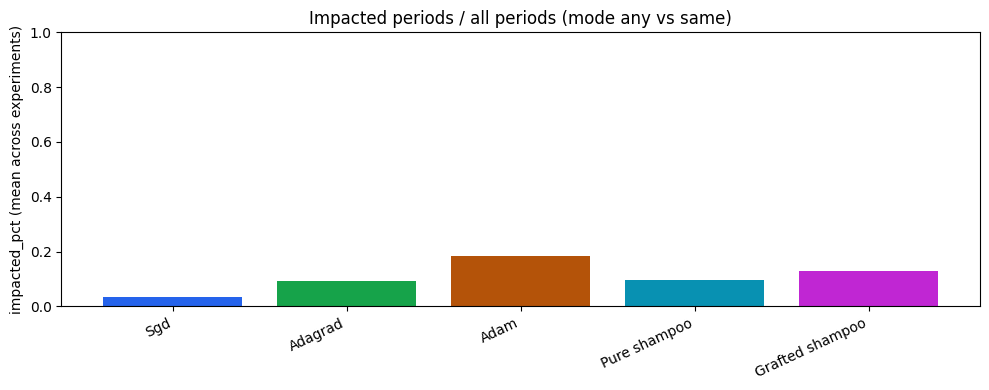

In [ ]:
# mean impacted_pct by optimizer (mean across experiments)
if not df_sum.empty:
	imp_by_opt = df_sum.groupby("optimizer_id", sort=False)["impacted_pct"].mean().reindex(_sort_optimizer_ids(df_sum["optimizer_id"].unique().tolist()))
	fig, ax = plt.subplots(figsize=(10, 4))
	x = np.arange(len(imp_by_opt))
	colors = [_opt_color(i) for i in imp_by_opt.index]
	ax.bar(x, imp_by_opt.values, color=colors)
	ax.set_xticks(x)
	ax.set_xticklabels([_opt_display(i) for i in imp_by_opt.index], rotation=25, ha="right")
	ax.set_ylabel("impacted_pct (mean across experiments)")
	ax.set_ylim(0, 1)
	ax.set_title("Impacted periods / all periods (mode any vs same)")
	plt.tight_layout()
	plt.show()


/tmp/ipykernel_17552/3784578917.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_len, x="optimizer_id", y="total_length_iter", order=order, palette=[_opt_color(o) for o in order], ax=ax)
/tmp/ipykernel_17552/3784578917.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([_opt_display(o) for o in order], rotation=25, ha="right")


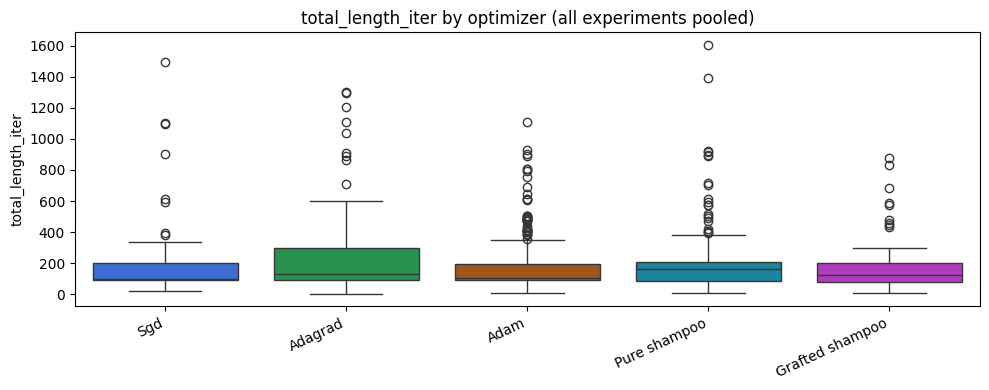

In [ ]:
# total_length_iter — one box per optimizer (all periods pooled)
length_records = []
for (eid, oid), v in all_results.items():
	for val in v["total_length_iter"]:
		length_records.append({"optimizer_id": oid, "optimizer": _opt_display(oid), "total_length_iter": val})
df_len = pd.DataFrame(length_records)
if not df_len.empty:
	order = _sort_optimizer_ids(df_len["optimizer_id"].unique().tolist())
	fig, ax = plt.subplots(figsize=(10, 4))
	sns.boxplot(data=df_len, x="optimizer_id", y="total_length_iter", order=order, palette=[_opt_color(o) for o in order], ax=ax)
	ax.set_xticklabels([_opt_display(o) for o in order], rotation=25, ha="right")
	ax.set_xlabel("")
	ax.set_title("total_length_iter by optimizer (all experiments pooled)")
	plt.tight_layout()
	plt.show()


ConfidenceInterval(low=np.float64(-2.9044604876727225), high=np.float64(2.779045205280696))
ConfidenceInterval(low=np.float64(-0.40444348915661044), high=np.float64(4.334031907438497))
ConfidenceInterval(low=np.float64(-2.684332880230916), high=np.float64(2.3797110314914205))
ConfidenceInterval(low=np.float64(-2.02667190968152), high=np.float64(2.83556915278929))
ConfidenceInterval(low=np.float64(0.34279967553518786), high=np.float64(3.7122040251387247))
ConfidenceInterval(low=np.float64(-2.0023469781394367), high=np.float64(1.8231404117919676))
ConfidenceInterval(low=np.float64(-1.3060630043845598), high=np.float64(2.2403755298843566))
ConfidenceInterval(low=np.float64(-3.16919182226495), high=np.float64(-1.065018444756432))
ConfidenceInterval(low=np.float64(-2.3253713621471044), high=np.float64(-0.7953198130270117))
ConfidenceInterval(low=np.float64(-0.6337273413456539), high=np.float64(1.7472464331929198))


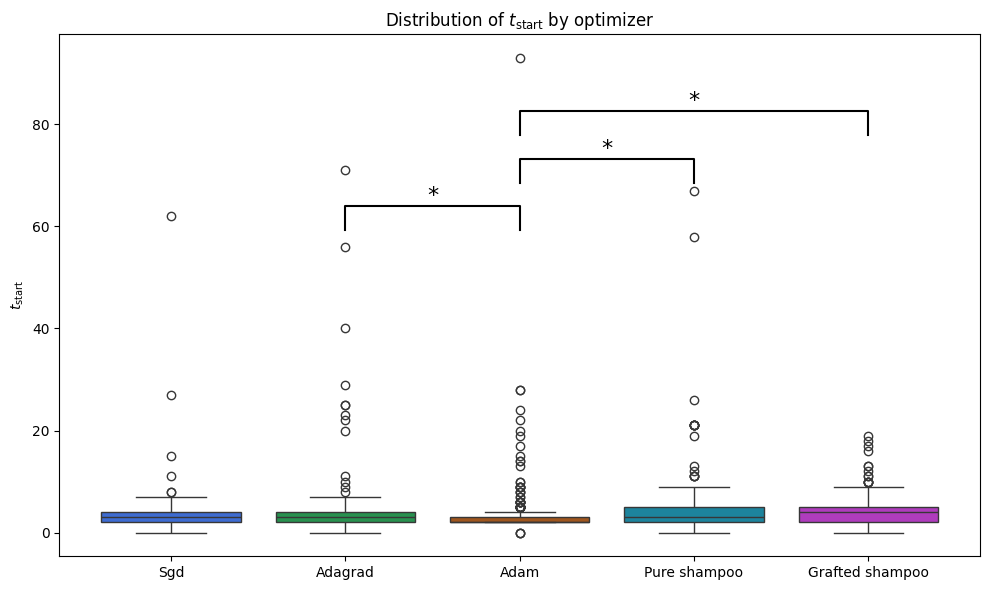

In [ ]:
# Welch t-test and significance plotting for point_of_max_acceleration by optimizer

import scipy.stats as stats

def is_significant(p_value, t_value, df):
	# Following https://socialsci.libretexts.org/Bookshelves/Linguistics/Corpus_Linguistics%3A_A_Guide_to_the_Methodology_(Stefanowitsch)/14%3A_Statistical_Tables/14.4%3A_Critical_values_for_Welch%27s_(t)-Test
	# Using https://www.sjsu.edu/faculty/gerstman/StatPrimer/t-table.pdf
	# p_columns = [1.00, 0.50, 0.40, 0.30, 0.20, 0.10, 0.05, 0.02, 0.01, 0.002, 0.001]
	# t_table = {
	# 	1:  [0.000,1.000,1.376,1.963,3.078,6.314,12.71,31.82,63.66,318.31,636.62],
	# 	2:  [0.000,0.816,1.061,1.386,1.886,2.920,4.303,6.965,9.925,22.327,31.599],
	# 	3:  [0.000,0.765,0.978,1.250,1.638,2.353,3.182,4.541,5.841,10.215,12.924],
	# 	4:  [0.000,0.741,0.941,1.190,1.533,2.132,2.776,3.747,4.604,7.173,8.610],
	# 	5:  [0.000,0.727,0.920,1.156,1.476,2.015,2.571,3.365,4.032,5.893,6.869],
	# 	10: [0.000,0.700,0.879,1.093,1.372,1.812,2.228,2.764,3.169,4.144,4.587],
	# 	20: [0.000,0.687,0.860,1.064,1.325,1.725,2.086,2.528,2.845,3.552,3.850],
	# 	30: [0.000,0.683,0.854,1.055,1.310,1.697,2.042,2.457,2.750,3.385,3.646],
	# 	1000: [0.000,0.675,0.842,1.037,1.282,1.646,1.962,2.330,2.581,3.098,3.300],
	# }
	# closest_df = min(t_table.keys(), key=lambda x: abs(x - df))
	# row = t_table[closest_df]

	# matched_p = None
	# for i in range(len(row)):
	# 	if t_value >= row[i]:
	# 		matched_p = p_columns[i]
	# 	else:
	# 		break

	# if matched_p is None:
	# 	return False

	# print(p_value, matched_p)
	return p_value <= 0.05

# Collect the data
pma_records = []
for (eid, oid), v in all_results.items():
	for val in v["points_of_max_acceleration"]:
		pma_records.append({"optimizer_id": oid, "optimizer": _opt_display(oid), "point_of_max_acceleration": val})
df_pma = pd.DataFrame(pma_records)

if not df_pma.empty:
	order = _sort_optimizer_ids(df_pma["optimizer_id"].unique().tolist())
	means = df_pma.groupby("optimizer_id")["point_of_max_acceleration"].mean().reindex(order)
	stds = df_pma.groupby("optimizer_id")["point_of_max_acceleration"].std().reindex(order)
	ns = df_pma.groupby("optimizer_id")["point_of_max_acceleration"].count().reindex(order)

	# Welch's t-test for all pairs (upper triangle)
	sig_pairs = []
	pairs = []
	pval_alpha = 0.05
	for i, opt_i in enumerate(order):
		for j, opt_j in enumerate(order):
			if i < j:
				vals_i = df_pma[df_pma["optimizer_id"] == opt_i]["point_of_max_acceleration"]
				vals_j = df_pma[df_pma["optimizer_id"] == opt_j]["point_of_max_acceleration"]
				# Welch T-test
				ttest_res = stats.ttest_ind(vals_i, vals_j, equal_var=False, nan_policy="raise")
				t_stat, p_two_tailed, dof = ttest_res.statistic, ttest_res.pvalue, ttest_res.df
				print(ttest_res.confidence_interval())
				significant = is_significant(p_two_tailed, abs(t_stat), int(round(dof)))
				if significant:
					sig_pairs.append((i, j, t_stat))
				pairs.append(((i, j), p_two_tailed, t_stat, dof, significant))

	# Plot
	fig, ax = plt.subplots(figsize=(10, 6))
	sns.boxplot(
		data=df_pma,
		x="optimizer_id",
		y="point_of_max_acceleration",
		hue="optimizer_id", 
		order=order,
		hue_order=order,
		palette=[_opt_color(o) for o in order],
		ax=ax,
		legend=False,
		whis=1.5
	)

	# set_xticklabels warning fix: ensure we have ticks set
	ax.set_xticks(np.arange(len(order)))
	ax.set_xticklabels([_opt_display(o) for o in order], ha="center")
	ax.set_xlabel("")
	ax.set_title(r"Distribution of $t_{\text{start}}$ by optimizer")
	ax.set_ylabel(r"$t_{\text{start}}$")

	# Add lines for significant pairs
	ymax = df_pma["point_of_max_acceleration"].max()
	y_offset = 0.1 * (df_pma["point_of_max_acceleration"].max() - df_pma["point_of_max_acceleration"].min())
	num_heights = 0
	plotted = set()
	for idx, (i, j, t_stat) in enumerate(sig_pairs):
		key = tuple(sorted((i, j)))
		if key in plotted:
			continue
		plotted.add(key)
		y = 50 + y_offset + idx * y_offset
		x1, x2 = i, j
		ax.plot([x1, x1, x2, x2], [y, y+y_offset/2, y+y_offset/2, y], lw=1.5, c="k")
		ax.text((x1 + x2) / 2, y + y_offset / 2, "*", ha="center", va="bottom", color="k", fontsize=16)
	plt.tight_layout()
	plt.savefig(PLOT_DIR + "distr_point_of_max_acceleration.pdf")
	plt.show()

In [ ]:
all_results[('pretrain_relabelC_0_1_2_K1000_tr100', 'pure_shampoo_lr0.01')]["mssim_rows"][0]

{'experiment_id': 'pretrain_relabelC_0_1_2_K1000_tr100',
 'optimizer_id': 'pure_shampoo_lr0.01',
 'layer_name': 'hidden.2',
 'mean_of_mssim': 0.2854513112987791}

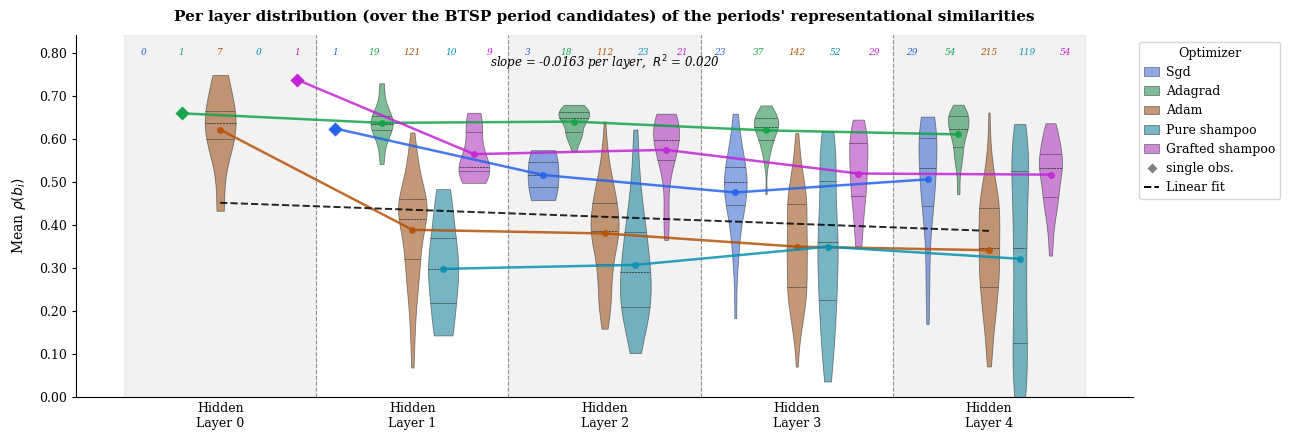

In [ ]:
# import matplotlib.pyplot as plt
# import matplotlib.ticker as mticker
# import seaborn as sns
# import numpy as np

# from visualize_webapp.notebook.scoring_constants import USE_CW_SSIM

# mssim_flat = [r for v in all_results.values() for r in v["mssim_rows"]]
# df_m = pd.DataFrame(mssim_flat)

# if not df_m.empty:
# 	layer_order = list(dict.fromkeys(
# 		df_m.sort_values(["experiment_id", "layer_name"])["layer_name"]
# 	))
# 	opt_order = _sort_optimizer_ids(df_m["optimizer_id"].unique().tolist())
# 	colors	= [_opt_color(o) for o in opt_order]
# 	labels	= [_opt_display(o) for o in opt_order]

# 	# ── Compute per (layer, optimizer) sample counts ───────────────────────────
# 	counts = (
# 		df_m.groupby(["layer_name", "optimizer_id"])["mean_of_mssim"]
# 		.count()
# 		.reset_index(name="n")
# 	)
# 	# ── Per (layer, optimizer) decision ───────────────────────────────────
# 	singleton_cells = set(
# 		counts.loc[counts["n"] <= 1, ["layer_name", "optimizer_id"]]
# 		.apply(tuple, axis=1)
# 	)

# 	# A layer needs violin if ANY optimizer in it has n > 1
# 	violin_layers = [
# 		l for l in layer_order
# 		if any((l, o) not in singleton_cells for o in opt_order)
# 	]
# 	# A layer is scatter-only if ALL optimizers have n <= 1
# 	scatter_only_layers = [
# 		l for l in layer_order
# 		if all((l, o) in singleton_cells for o in opt_order)
# 	]
# 	with plt.rc_context({
# 		"font.family":		   "serif",
# 		"font.serif":			["Times New Roman", "DejaVu Serif"],
# 		"axes.spines.top":	   False,
# 		"axes.spines.right":	 False,
# 		"axes.linewidth":		0.8,
# 		"xtick.major.size":	  0,
# 		"ytick.major.size":	  3,
# 		"xtick.labelsize":	   9,
# 		"ytick.labelsize":	   9,
# 		"axes.labelsize":		10,
# 		"axes.titlesize":		11,
# 		"axes.titlepad":		 10,
# 		"legend.fontsize":	   9,
# 		"legend.title_fontsize": 9,
# 	}):
# 		fig, ax = plt.subplots(figsize=(13, 4.5))

# 		# ── Violin for layers with sufficient data ─────────────────────────────
# 		if violin_layers:
# 			df_violin = df_m[
# 			~df_m.apply(lambda r: (r["layer_name"], r["optimizer_id"]) in singleton_cells, axis=1)
# 		]

# 			sns.violinplot(
# 				data=df_violin,
# 				x="layer_name",
# 				y="mean_of_mssim",
# 				hue="optimizer_id",
# 				order=layer_order,
# 				hue_order=opt_order,
# 				palette=colors,
# 				cut=0,
# 				linewidth=0.6,
# 				inner="quartile",
# 				ax=ax,
# 				alpha=0.6,
# 			)
# 			# ── Extract exact violin centers from seaborn's patch objects
# 		from collections import defaultdict
# 		violin_centers = defaultdict(dict)

# 		patch_idx = 0
# 		for layer_idx, layer in enumerate(layer_order):
# 			for opt in opt_order:
# 				subset = df_m[(df_m["layer_name"] == layer) & (df_m["optimizer_id"] == opt)]
# 				if (layer, opt) in singleton_cells or subset.empty:
# 					continue
# 				if patch_idx < len(ax.collections):
# 					x_center = np.mean(ax.collections[patch_idx].get_paths()[0].vertices[:, 0])
# 					violin_centers[layer_idx][opt] = x_center
# 					patch_idx += 1

# 		# ── Per-optimizer linear fits (raw data, alpha=0.3) ────────────────────
# 		x_range = np.array([0, len(layer_order) - 1])
# 		opt_fit_handles = []  # collected below for legend

# 		for opt, color in zip(opt_order, colors):
# 			x_opt, y_opt = [], []
# 			for i, layer in enumerate(layer_order):
# 				subset = df_m[(df_m["layer_name"] == layer) & (df_m["optimizer_id"] == opt)]
# 				if not subset.empty:
# 					x_opt.extend([i] * len(subset))
# 					y_opt.extend(subset["mean_of_mssim"].tolist())

# 			if len(x_opt) > 1:
# 				slope_o, intercept_o, _, _, _ = stats.linregress(x_opt, y_opt)
# 				y_fit = slope_o * x_range + intercept_o
# 				line, = ax.plot(
# 					x_range, y_fit,
# 					color=color,
# 					linewidth=1.2,
# 					linestyle="--",
# 					alpha=0.3,
# 					zorder=6,
# 				)

# 		# ── Global demeaned linear fit (alpha=0.9) ─────────────────────────────
# 		# Demean per (optimizer, layer) group so group-level mean differences
# 		# don't bias the slope estimate
# 		df_m["mssim_demeaned"] = (
# 			df_m["mean_of_mssim"]
# 			- df_m.groupby(["optimizer_id", "layer_name"])["mean_of_mssim"].transform("mean")
# 		)

# 		x_all, y_all = [], []
# 		# Also collect raw x/y for the intercept anchor
# 		x_all_raw, y_all_raw = [], []
# 		for i, layer in enumerate(layer_order):
# 			subset = df_m[df_m["layer_name"] == layer]
# 			if not subset.empty:
# 				x_all.extend([i] * len(subset))
# 				y_all.extend(subset["mssim_demeaned"].tolist())
# 				x_all_raw.extend([i] * len(subset))
# 				y_all_raw.extend(subset["mean_of_mssim"].tolist())

# 		if len(x_all) > 1:
# 			slope, _, r_value, _, _ = stats.linregress(x_all, y_all)
# 			_, intercept, _, _, _  = stats.linregress(x_all_raw, y_all_raw)

# 			y_global = slope * x_range + intercept
# 			ax.plot(
# 				x_range, y_global,
# 				color="black",
# 				linewidth=1.6,
# 				linestyle="--",
# 				alpha=0.9,
# 				zorder=7,
# 			)
# 			ax.text(
# 				0.5, 0.95,
# 				f"Global fit (demeaned): slope = {slope:+.4f} per layer,  $R^2$ = {r_value**2:.3f}",
# 				transform=ax.transAxes,
# 				ha="center", va="top", fontsize=8.5, fontstyle="italic", color="black",
# 			)

# 		# ── Scatter for singleton cells (n<=1) ────────────────────────────────
# 		layer_pos = {name: i for i, name in enumerate(layer_order)}
# 		opt_color_map = {o: c for o, c in zip(opt_order, colors)}
# 		n_opts = len(opt_order)
# 		dodge_offsets = np.linspace(-0.4, 0.4, n_opts) if n_opts > 1 else [0.0]
# 		opt_offset = {o: dodge_offsets[j] for j, o in enumerate(opt_order)}

# 		for opt in opt_order:
# 			df_opt = df_m[
# 				df_m.apply(lambda r: (r["layer_name"], r["optimizer_id"]) in singleton_cells
# 						   and r["optimizer_id"] == opt, axis=1)
# 			]
# 			if df_opt.empty:
# 				continue
# 			xpos = [layer_pos[l] + opt_offset[opt] for l in df_opt["layer_name"]]
# 			ax.scatter(
# 				xpos, df_opt["mean_of_mssim"],
# 				color=opt_color_map[opt],
# 				s=60, zorder=5, linewidths=0.5,
# 				edgecolors="white", marker="D",
# 			)

# 		# ── Mean lines across layers per optimizer ────────────────────────────
# 		for opt in opt_order:
# 			means = []
# 			xpos_list = []
# 			for i, layer in enumerate(layer_order):
# 				subset = df_m[(df_m["layer_name"] == layer) & (df_m["optimizer_id"] == opt)]
# 				if not subset.empty:
# 					means.append(subset["mean_of_mssim"].mean())
# 					if opt in violin_centers[i]:
# 						xpos_list.append(violin_centers[i][opt])
# 					else:
# 						xpos_list.append(i + opt_offset[opt])
# 			if len(xpos_list) > 1:
# 				ax.plot(
# 					xpos_list, means,
# 					color=opt_color_map[opt],
# 					linewidth=1.8,
# 					linestyle="-",
# 					marker="o",
# 					markersize=4,
# 					zorder=6,
# 					alpha=0.85,
# 				)

# 		# ── Dashed vertical separators ─────────────────────────────────────────
# 		n_layers = len(layer_order)
# 		for x in np.arange(0.5, n_layers - 0.5, 1.0):
# 			ax.axvline(x, color="gray", linewidth=0.8, linestyle="--",
# 					   alpha=0.8, zorder=0)

# 		# ── Alternating bands ──────────────────────────────────────────────────
# 		for i in range(0, n_layers, 2):
# 			ax.axvspan(i - 0.5, i + 0.5, color="gray", alpha=0.1, zorder=0)

# 		# ── N annotations above each layer ────────────────────────────────────
# 		y_top = ax.get_ylim()[1]
# 		n_opts = len(opt_order)
# 		dodge_offsets = np.linspace(-0.4, 0.4, n_opts) if n_opts > 1 else [0.0]

# 		for i, layer in enumerate(layer_order):
# 			for j, opt in enumerate(opt_order):
# 				row = counts[
# 					(counts["layer_name"] == layer) &
# 					(counts["optimizer_id"] == opt)
# 				]
# 				n = int(row["n"].values[0]) if len(row) else 0
# 				xpos = i + dodge_offsets[j]
# 				ax.text(
# 					xpos, y_top * 1.005,
# 					str(n),
# 					ha="center", va="bottom",
# 					fontsize=6.5,
# 					color=opt_color_map[opt],
# 					fontstyle="italic",
# 				)
# 		y_min = max(0, df_m["mean_of_mssim"].min() - 0.02)

# 		# ── Axes & labels ──────────────────────────────────────────────────────
# 		ax.set_xlabel("")
# 		ax.set_ylabel(r"$\rho(b_i)$", labelpad=8)
# 		ax.set_title(
# 			f"Per layer distribution (over the BTSP period candidates) of the periods' representational similarities",
# 			fontweight="bold",
# 		)
# 		ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
# 		ax.set_ylim(bottom=y_min, top=y_top * 1.07)
# 		ax.set_xticks(range(n_layers))
# 		def parse_ln(ln):
# 			return "Hidden\nLayer " + str(int(ln.split(".")[-1])//2)
# 		ax.set_xticklabels([parse_ln(ln) for ln in layer_order], ha="center")

# 		# ── Legend ─────────────────────────────────────────────────────────────
# 		handles, _ = ax.get_legend_handles_labels()
# 		from matplotlib.lines import Line2D

# 		# Per-optimizer fit lines (faint, colored dashes)
# 		per_opt_fit_handles = [
# 			Line2D([0], [0], color=opt_color_map[o], linewidth=1.2,
# 				   linestyle="--", alpha=0.3, label=f"Linear fit – {_opt_display(o)}")
# 			for o in opt_order
# 		]
# 		# Global demeaned fit (bold black dash)
# 		global_fit_handle = Line2D(
# 			[0], [0], color="black", linewidth=1.6, linestyle="--", alpha=0.9,
# 			label=f"Global fit (demeaned, slope={slope:+.4f}, $R^2$={r_value**2:.3f})"
# 		)
# 		# Single-obs marker
# 		single_obs_handle = Line2D(
# 			[0], [0], marker="D", color="w", markerfacecolor="gray",
# 			markersize=6, label="single obs."
# 		)

# 		ax.legend(
# 			handles[:len(opt_order)] + per_opt_fit_handles + [global_fit_handle, single_obs_handle],
# 			labels + [h.get_label() for h in per_opt_fit_handles] + [global_fit_handle.get_label(), "single obs."],
# 			title="Optimizer",
# 			bbox_to_anchor=(1.0, 1),
# 			loc="upper left",
# 			handlelength=1.2,
# 			handletextpad=0.5,
# 		)

# 		fig.tight_layout()
# 		plt.savefig(PLOT_DIR+"per_layer_repr_similarity.pdf", dpi=300, bbox_inches="tight")
# 		plt.show()

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

mssim_flat = [r for v in all_results.values() for r in v["mssim_rows"]]
df_m = pd.DataFrame(mssim_flat)

if not df_m.empty:
	layer_order = list(dict.fromkeys(
		df_m.sort_values(["experiment_id", "layer_name"])["layer_name"]
	))
	opt_order = _sort_optimizer_ids(df_m["optimizer_id"].unique().tolist())
	colors	= [_opt_color(o) for o in opt_order]
	labels	= [_opt_display(o) for o in opt_order]

	# ── Compute per (layer, optimizer) sample counts ───────────────────────────
	counts = (
		df_m.groupby(["layer_name", "optimizer_id"])["mean_of_mssim"]
		.count()
		.reset_index(name="n")
	)
	# ── Per (layer, optimizer) decision ───────────────────────────────────
	singleton_cells = set(
		counts.loc[counts["n"] <= 1, ["layer_name", "optimizer_id"]]
		.apply(tuple, axis=1)
	)

	# A layer needs violin if ANY optimizer in it has n > 1
	violin_layers = [
		l for l in layer_order
		if any((l, o) not in singleton_cells for o in opt_order)
	]
	# A layer is scatter-only if ALL optimizers have n <= 1
	scatter_only_layers = [
		l for l in layer_order
		if all((l, o) in singleton_cells for o in opt_order)
	]
	with plt.rc_context({
		"font.family":		   "serif",
		"font.serif":			["Times New Roman", "DejaVu Serif"],
		"axes.spines.top":	   False,
		"axes.spines.right":	 False,
		"axes.linewidth":		0.8,
		"xtick.major.size":	  0,
		"ytick.major.size":	  3,
		"xtick.labelsize":	   9,
		"ytick.labelsize":	   9,
		"axes.labelsize":		10,
		"axes.titlesize":		11,
		"axes.titlepad":		 10,
		"legend.fontsize":	   9,
		"legend.title_fontsize": 9,
	}):
		fig, ax = plt.subplots(figsize=(13, 4.5))

		# ── Violin for layers with sufficient data ─────────────────────────────
		if violin_layers:
			df_violin = df_m[
			~df_m.apply(lambda r: (r["layer_name"], r["optimizer_id"]) in singleton_cells, axis=1)
		]

			sns.violinplot(
				data=df_violin,
				x="layer_name",
				y="mean_of_mssim",
				hue="optimizer_id",
				order=layer_order,
				hue_order=opt_order,
				palette=colors,
				cut=0,
				linewidth=0.6,
				inner="quartile",
				ax=ax,
				alpha=0.6,
			)
			# ── Extract exact violin centers from seaborn's patch objects
		from collections import defaultdict
		violin_centers = defaultdict(dict)

		patch_idx = 0
		for layer_idx, layer in enumerate(layer_order):
			for opt in opt_order:
				subset = df_m[(df_m["layer_name"] == layer) & (df_m["optimizer_id"] == opt)]
				if (layer, opt) in singleton_cells or subset.empty:
					continue
				if patch_idx < len(ax.collections):
					x_center = np.mean(ax.collections[patch_idx].get_paths()[0].vertices[:, 0])
					violin_centers[layer_idx][opt] = x_center
					patch_idx += 1

		# ── Per-optimizer linear fits (raw data, alpha=0.3) ────────────────────
		x_range = np.array([0, len(layer_order) - 1])
		opt_fit_handles = []  # collected below for legend

		for opt, color in zip(opt_order, colors):
			x_opt, y_opt = [], []
			for i, layer in enumerate(layer_order):
				subset = df_m[(df_m["layer_name"] == layer) & (df_m["optimizer_id"] == opt)]
				if not subset.empty:
					x_opt.extend([i] * len(subset))
					y_opt.extend(subset["mean_of_mssim"].tolist())

			if len(x_opt) > 1:
				slope_o, intercept_o, _, _, _ = stats.linregress(x_opt, y_opt)
				y_fit = slope_o * x_range + intercept_o
				line, = ax.plot(
					x_range, y_fit,
					color=color,
					linewidth=1.2,
					linestyle="--",
					alpha=0.3,
					zorder=6,
				)

		# ── Global demeaned linear fit (alpha=0.9) ─────────────────────────────
		# Demean per (optimizer, layer) group so group-level mean differences
		# don't bias the slope estimate
		df_m["mssim_demeaned"] = (
			df_m["mean_of_mssim"]
			- df_m.groupby(["optimizer_id", "layer_name"])["mean_of_mssim"].transform("mean")
		)

		x_all, y_all = [], []
		# Also collect raw x/y for the intercept anchor
		x_all_raw, y_all_raw = [], []
		for i, layer in enumerate(layer_order):
			subset = df_m[df_m["layer_name"] == layer]
			if not subset.empty:
				x_all.extend([i] * len(subset))
				y_all.extend(subset["mssim_demeaned"].tolist())
				x_all_raw.extend([i] * len(subset))
				y_all_raw.extend(subset["mean_of_mssim"].tolist())

		if len(x_all) > 1:
			slope, _, r_value, _, _ = stats.linregress(x_all, y_all)
			_, intercept, _, _, _  = stats.linregress(x_all_raw, y_all_raw)

			y_global = slope * x_range + intercept
			ax.plot(
				x_range, y_global,
				color="black",
				linewidth=1.6,
				linestyle="--",
				alpha=0.9,
				zorder=7,
			)
			ax.text(
				0.5, 0.95,
				f"Global fit (demeaned): slope = {slope:+.4f} per layer,  $R^2$ = {r_value**2:.3f}",
				transform=ax.transAxes,
				ha="center", va="top", fontsize=8.5, fontstyle="italic", color="black",
			)

		# ── Scatter for singleton cells (n<=1) ────────────────────────────────
		layer_pos = {name: i for i, name in enumerate(layer_order)}
		opt_color_map = {o: c for o, c in zip(opt_order, colors)}
		n_opts = len(opt_order)
		dodge_offsets = np.linspace(-0.4, 0.4, n_opts) if n_opts > 1 else [0.0]
		opt_offset = {o: dodge_offsets[j] for j, o in enumerate(opt_order)}

		for opt in opt_order:
			df_opt = df_m[
				df_m.apply(lambda r: (r["layer_name"], r["optimizer_id"]) in singleton_cells
						   and r["optimizer_id"] == opt, axis=1)
			]
			if df_opt.empty:
				continue
			xpos = [layer_pos[l] + opt_offset[opt] for l in df_opt["layer_name"]]
			ax.scatter(
				xpos, df_opt["mean_of_mssim"],
				color=opt_color_map[opt],
				s=60, zorder=5, linewidths=0.5,
				edgecolors="white", marker="D",
			)

		# ── Mean lines across layers per optimizer ────────────────────────────
		for opt in opt_order:
			means = []
			xpos_list = []
			for i, layer in enumerate(layer_order):
				subset = df_m[(df_m["layer_name"] == layer) & (df_m["optimizer_id"] == opt)]
				if not subset.empty:
					means.append(subset["mean_of_mssim"].mean())
					if opt in violin_centers[i]:
						xpos_list.append(violin_centers[i][opt])
					else:
						xpos_list.append(i + opt_offset[opt])
			if len(xpos_list) > 1:
				ax.plot(
					xpos_list, means,
					color=opt_color_map[opt],
					linewidth=1.8,
					linestyle="-",
					marker="o",
					markersize=4,
					zorder=6,
					alpha=0.85,
				)

		# ── Dashed vertical separators ─────────────────────────────────────────
		n_layers = len(layer_order)
		for x in np.arange(0.5, n_layers - 0.5, 1.0):
			ax.axvline(x, color="gray", linewidth=0.8, linestyle="--",
					   alpha=0.8, zorder=0)

		# ── Alternating bands ──────────────────────────────────────────────────
		for i in range(0, n_layers, 2):
			ax.axvspan(i - 0.5, i + 0.5, color="gray", alpha=0.1, zorder=0)

		# ── N annotations above each layer ────────────────────────────────────
		y_top = ax.get_ylim()[1]
		n_opts = len(opt_order)
		dodge_offsets = np.linspace(-0.4, 0.4, n_opts) if n_opts > 1 else [0.0]

		for i, layer in enumerate(layer_order):
			for j, opt in enumerate(opt_order):
				row = counts[
					(counts["layer_name"] == layer) &
					(counts["optimizer_id"] == opt)
				]
				n = int(row["n"].values[0]) if len(row) else 0
				xpos = i + dodge_offsets[j]
				ax.text(
					xpos, y_top * 1.005,
					str(n),
					ha="center", va="bottom",
					fontsize=6.5,
					color=opt_color_map[opt],
					fontstyle="italic",
				)
		y_min = max(0, df_m["mean_of_mssim"].min() - 0.02)

		# ── Axes & labels ──────────────────────────────────────────────────────
		ax.set_xlabel("")
		ax.set_ylabel(r"$\rho(b_i)$", labelpad=8)
		ax.set_title(
			f"Per layer distribution (over the BTSP period candidates) of the periods' representational similarities",
			fontweight="bold",
		)
		ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
		ax.set_ylim(bottom=y_min, top=y_top * 1.07)
		ax.set_xticks(range(n_layers))
		def parse_ln(ln):
			return "Hidden\nLayer " + str(int(ln.split(".")[-1])//2)
		ax.set_xticklabels([parse_ln(ln) for ln in layer_order], ha="center")

		# ── Legend ─────────────────────────────────────────────────────────────
		handles, _ = ax.get_legend_handles_labels()
		from matplotlib.lines import Line2D

		# Per-optimizer fit lines (faint, colored dashes)
		per_opt_fit_handles = [
			Line2D([0], [0], color=opt_color_map[o], linewidth=1.2,
				   linestyle="--", alpha=0.3, label=f"Linear fit – {_opt_display(o)}")
			for o in opt_order
		]
		# Global demeaned fit (bold black dash)
		global_fit_handle = Line2D(
			[0], [0], color="black", linewidth=1.6, linestyle="--", alpha=0.9,
			label=f"Global fit (demeaned, slope={slope:+.4f}, $R^2$={r_value**2:.3f})"
		)
		# Single-obs marker
		single_obs_handle = Line2D(
			[0], [0], marker="D", color="w", markerfacecolor="gray",
			markersize=6, label="single obs."
		)

		ax.legend(
			handles[:len(opt_order)] + per_opt_fit_handles + [global_fit_handle, single_obs_handle],
			labels + [h.get_label() for h in per_opt_fit_handles] + [global_fit_handle.get_label(), "single obs."],
			title="Optimizer",
			bbox_to_anchor=(1.0, 1),
			loc="upper left",
			handlelength=1.2,
			handletextpad=0.5,
		)

		fig.tight_layout()
		plt.savefig(PLOT_DIR+"per_layer_repr_similarity.pdf", dpi=300, bbox_inches="tight")
		plt.show()

In [ ]:
assert False

In [ ]:
# Saliency tensors are no longer saved in ``score_run`` outputs — only ``period_robustness_rows``,
# ``mssim_rows``, and aggregate scores are persisted (smaller ``results.pkl.gz``).


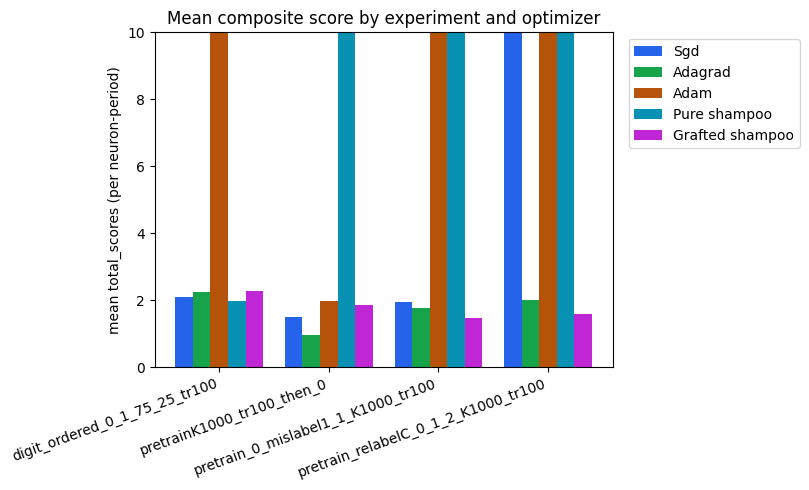

In [ ]:
# mean total score per experiment — grouped bars per optimizer
if not df_sum.empty:
	pivot = df_sum.pivot_table(
		index="experiment_id", columns="optimizer_id", values="mean_total_score", aggfunc="mean"
	)
	cols = _sort_optimizer_ids([c for c in pivot.columns if pd.notna(c)])
	pivot = pivot[cols]
	experiments = list(pivot.index)
	x = np.arange(len(experiments))
	n = len(cols)
	width = 0.8 / max(n, 1)
	fig, ax = plt.subplots(figsize=(max(8, len(experiments) * 1.2), 5))
	for i, oid in enumerate(cols):
		off = (i - (n - 1) / 2) * width
		vals = [pivot.loc[e, oid] if e in pivot.index and np.isfinite(pivot.loc[e, oid]) else np.nan for e in experiments]
		ax.bar(x + off, vals, width, label=_opt_display(oid), color=_opt_color(oid))
	ax.set_xticks(x)
	ax.set_xticklabels(experiments, rotation=20, ha="right")
	ax.set_ylabel("mean total_scores (per neuron-period)")
	ax.set_title("Mean composite score by experiment and optimizer")
	ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
	plt.tight_layout()
	plt.show()


In [ ]:
pd.DataFrame(all_results)['pretrainK1000_tr100_then_0',	'pure_shampoo_lr0.01'].keys()

Index(['eid', 'mid', 'oid', 'rid', 'impacted_pct', 'total_length_iter',
       'points_of_max_acceleration', 'mean_total_score', 'mssim_rows',
       'n_periods', 'period_robustness_rows'],
      dtype='str')

In [ ]:
pd.DataFrame(all_results)['pretrainK1000_tr100_then_0',	'pure_shampoo_lr0.01']["period_robustness_rows"]

[{'experiment_id': 'pretrainK1000_tr100_then_0',
  'optimizer_id': 'pure_shampoo_lr0.01',
  'neuron_id': 'dnn|hidden.6|neuron|29',
  'period_id': 0,
  'layer_name': 'hidden.6',
  'n_checkpoints': 99,
  'd_bar': -0.4883562934845144,
  'robustness': 0.08875957891870716,
  'd_tk': [-0.5248096236853271,
   -0.5286033299950317,
   -0.5295967157899846,
   -0.5259071367145564,
   -0.5453448936439496,
   -0.5047426252054195,
   -0.5044428068631556,
   -0.5044356589367386,
   -0.5042716633903251,
   -0.5041077348229869,
   -0.5049439697923748,
   -0.5045697923480439,
   -0.5045712979204334,
   -0.5030252369595126,
   -0.5028744093389732,
   -0.5048230449870772,
   -0.5066253239103464,
   -0.5045822661070395,
   -0.5089125271618725,
   -0.4743833212412209,
   -0.46622197314896624,
   -0.4357021416976913,
   -0.4335062756885189,
   -0.43568033449159616,
   -0.43469935565070833,
   -0.39008795819233966,
   -0.3835359064785561,
   -0.41839753182669825,
   -0.4186972825567502,
   -0.4185221958914251